In [2]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
import os
import pandas as pd
import numpy as np

if os.path.exists('saved_analysis_state/data/df_filtered.parquet'):
    df = pd.read_parquet('saved_analysis_state/data/df_filtered.parquet')
    print(f"Loaded {len(df)} rows with {len(df.columns)} columns")
    print(df.info())
else:
    print("File not found. Check your path.")

Loaded 56025 rows with 7 columns
<class 'pandas.DataFrame'>
RangeIndex: 56025 entries, 0 to 56024
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_id                  56025 non-null  str           
 1   snapshot_date                56025 non-null  datetime64[ms]
 2   had_activity                 56025 non-null  bool          
 3   months_since_first_purchase  56025 non-null  float64       
 4   recency_days                 55832 non-null  float64       
 5   frequency                    56025 non-null  float64       
 6   monetary_value               56025 non-null  float64       
dtypes: bool(1), datetime64[ms](1), float64(4), str(1)
memory usage: 3.0 MB
None


GLOBAL TEMPORAL TREND ANALYSIS

--- Trend Summary ---
avg_monetary        : INCREASING (+3.1% over full period)
avg_frequency       : INCREASING (+53.0% over full period)
avg_recency         : DECREASING (+nan% over full period)
active_ratio        : DECREASING (+0.0% over full period)

--- Linear Trend Slopes (per day) ---
avg_monetary        : slope = 0.343804 per time step  (p=0.0710)
avg_frequency       : slope = 0.296004 per time step  (p=0.0005)
avg_recency         : slope = 1.837682 per time step  (p=0.0162)
active_ratio        : slope = 0.000935 per time step  (p=0.8720)


C:\Users\abduh\AppData\Local\Temp\ipykernel_11444\822351798.py:24: RuntimeWarning: invalid value encountered in scalar divide
  pct_change = ((end_val - start_val) / start_val) * 100


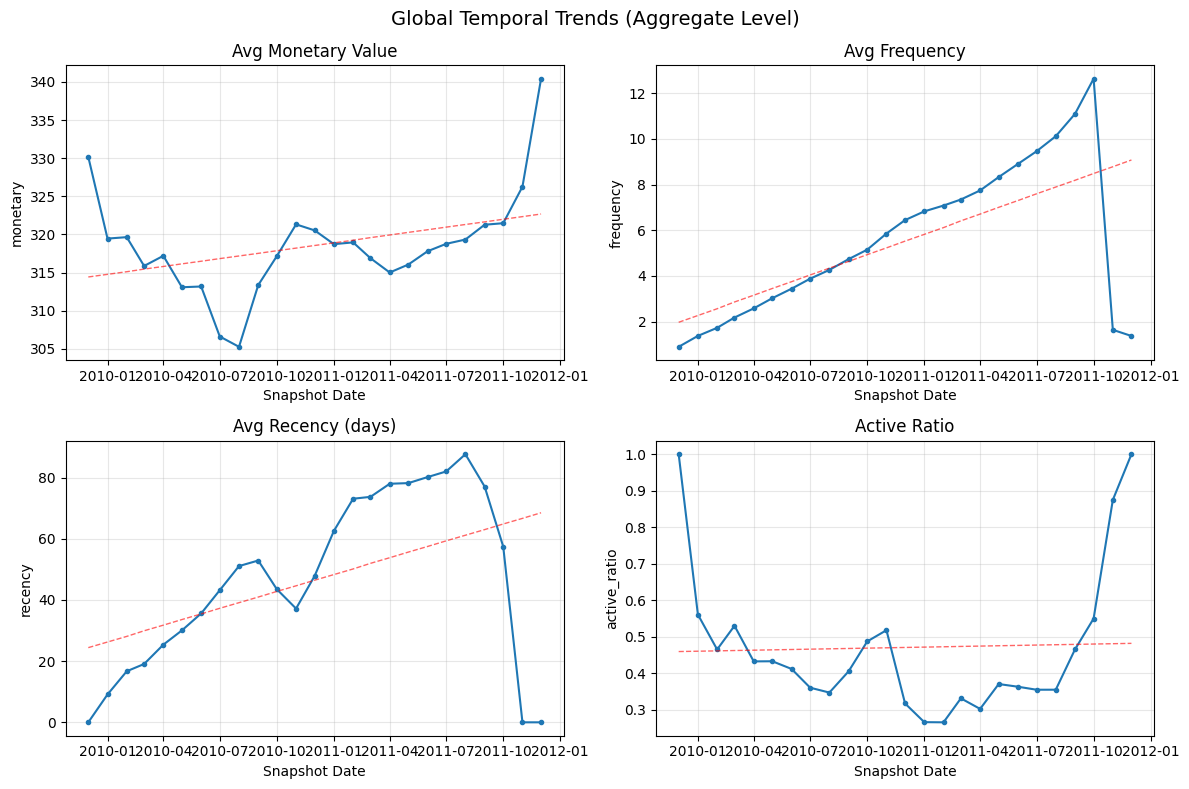

avg_monetary        : +3.10% change
avg_frequency       : +53.04% change
avg_recency         : +0.00% change
active_ratio        : +0.00% change

--- Implications by Metric ---
• FREQUENCY : Customers are buying more often.
  Use slower decay (α=0.95) to retain historical pattern weight

--- Recommended Action ---
MODERATE TEMPORAL DRIFT: Some metrics show meaningful change.
rolling window validation is RECOMMENDED
Retrain quarterly or use expanding windows


In [4]:
# GLOBAL TEMPORAL TREND ANALYSIS (AGGREGATE LEVEL)
import matplotlib.pyplot as plt
from scipy import stats

# Create aggregate metrics per snapshot_date
agg = df.groupby('snapshot_date').agg(
    avg_monetary=('monetary_value', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_recency=('recency_days', 'mean'),
    active_ratio=('had_activity', 'mean')
).reset_index()

# Sort by date just in case
agg = agg.sort_values('snapshot_date').reset_index(drop=True)


print("GLOBAL TEMPORAL TREND ANALYSIS")
print("=" * 60)

print("\n--- Trend Summary ---")
for col in ['avg_monetary', 'avg_frequency', 'avg_recency', 'active_ratio']:
    start_val = agg[col].iloc[0]
    end_val = agg[col].iloc[-1]
    pct_change = ((end_val - start_val) / start_val) * 100
    direction = "INCREASING" if end_val > start_val else "DECREASING"
    print(f"{col:20s}: {direction} ({pct_change:+.1f}% over full period)")

# Simple linear trend (slope) for each metric
print("\n--- Linear Trend Slopes (per day) ---")
x = np.arange(len(agg))  # time steps (0,1,2,...)
for col in ['avg_monetary', 'avg_frequency', 'avg_recency', 'active_ratio']:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, agg[col])
    print(f"{col:20s}: slope = {slope:.6f} per time step  (p={p_value:.4f})")

# Visualize the four trends 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Global Temporal Trends (Aggregate Level)', fontsize=14)

metrics = ['avg_monetary', 'avg_frequency', 'avg_recency', 'active_ratio']
titles = ['Avg Monetary Value', 'Avg Frequency', 'Avg Recency (days)', 'Active Ratio']

for ax, col, title in zip(axes.flat, metrics, titles):
    ax.plot(agg['snapshot_date'], agg[col], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Snapshot Date')
    ax.set_ylabel(col.replace('avg_', ''))
    ax.grid(True, alpha=0.3)
    # Add a simple trend line
    z = np.polyfit(range(len(agg)), agg[col], 1)
    p = np.poly1d(z)
    ax.plot(agg['snapshot_date'], p(range(len(agg))), "r--", alpha=0.6, linewidth=1)

plt.tight_layout()
plt.savefig('fig4.png', dpi=300, bbox_inches='tight')
plt.show()

# Check for practical significance (not just statistical)

metrics_to_check = {
    'avg_monetary': 'monetary_value',
    'avg_frequency': 'frequency', 
    'avg_recency': 'recency_days',
    'active_ratio': 'had_activity'
}
significant_trends = []
for col, name in metrics_to_check.items():
    start_val = agg[col].iloc[0]
    end_val = agg[col].iloc[-1]
    # Avoid division by zero for active_ratio if start is 0
    if start_val == 0:
        rel_change = float('inf') if end_val > 0 else 0
    else:
        rel_change = (end_val - start_val) / start_val
    
    print(f"{col:20s}: {rel_change:+.2%} change")
    
    # Threshold: 5% change is practically meaningful
    if abs(rel_change) > 0.05:
        significant_trends.append(col)

print("\n--- Implications by Metric ---")

# Monetary implications
if 'avg_monetary' in significant_trends:
    if agg['avg_monetary'].iloc[-1] > agg['avg_monetary'].iloc[0]:
        print("• MONETARY : High-value customers are becoming more valuable.")
        print("   Increase weights for top decile (use 5x-10x weighting)")
        print("   Shorter retraining cycles to capture growth")
    else:
        print("• MONETARY : Customer spending power is eroding.")
        print("  Transfer learning may be needed if this is a market trend")
        print("   Lower monetary = higher churn hazard")

# Frequency implications
if 'avg_frequency' in significant_trends:
    if agg['avg_frequency'].iloc[-1] > agg['avg_frequency'].iloc[0]:
        print("• FREQUENCY : Customers are buying more often.")
        print("  Use slower decay (α=0.95) to retain historical pattern weight")
    else:
        print("• FREQUENCY : Purchase cycles are lengthening.")
        print("   Use faster decay (α=0.7-0.8); recent behavior matters more")
        print("   This is an early churn indicator - prioritize hazard features")

# Recency implications (note: recency INCREASING is bad)
if 'avg_recency' in significant_trends:
    if agg['avg_recency'].iloc[-1] > agg['avg_recency'].iloc[0]:
        print("• RECENCY  (WORSENING): Customers are taking longer between purchases.")
        print("   Censored data is increasing - strengthen survival analysis")
        print("   Hazard rates are rising - critical for non-contractual CLV")
    else:
        print("• RECENCY (IMPROVING): Customers are responding faster.")
        print("   Recent behavior is highly predictive - use α=0.9-0.95")

# Active ratio implications
if 'active_ratio' in significant_trends:
    if agg['active_ratio'].iloc[-1] > agg['active_ratio'].iloc[0]:
        print("• ACTIVE RATIO: Customer base is growing or re-engaging.")
        print("  Batch retraining may be sufficient")
    else:
        print("• ACTIVE RATIO : Customer base is shrinking.")
        print("  Concept drift is likely - implement Page-Hinkley detection")
        print("  Mandatory rolling window validation")

print("\n--- Recommended Action ---")
if len(significant_trends) >= 3:
    print("HIGH TEMPORAL INSTABILITY: Multiple metrics trending.")
    print("online learning and real-time prediction are ESSENTIAL")
    print("Implement monthly retraining with drift detection")
elif len(significant_trends) >= 1:
    print("MODERATE TEMPORAL DRIFT: Some metrics show meaningful change.")
    print("rolling window validation is RECOMMENDED")
    print("Retrain quarterly or use expanding windows")
else:
    print("STABLE ENVIRONMENT: No metric changed by >5%.")
    print("→ Simple batch retraining (yearly) may be SUFFICIENT")
    print("→ Gradient boosting still adds value for non-linearity, but temporal complexity is low")

In [5]:
# Check recency distribution across customers
print(df.groupby('snapshot_date')['recency_days'].describe()[['mean', 'std', '50%']])

# Check if recency varies by had_activity
print(df.groupby('had_activity')['recency_days'].describe())

                    mean         std   50%
snapshot_date                             
2009-12-01      0.000000    0.000000   0.0
2010-01-01      9.108502   11.074503   0.0
2010-02-01     16.695338   22.415744   3.0
2010-03-01     19.071082   28.649380   0.0
2010-04-01     25.385956   35.842919   6.0
2010-05-01     30.065801   42.717515   5.0
2010-06-01     35.604856   49.072405  11.0
2010-07-01     43.203876   56.055657  19.0
2010-08-01     51.090838   63.630566  25.0
2010-09-01     52.905775   70.439049  16.0
2010-10-01     43.510585   70.952206   1.0
2010-11-01     37.192118   67.688894   0.0
2010-12-01     47.896377   73.295794  16.0
2011-01-01     62.594932   77.770944  38.0
2011-02-01     73.110786   84.629494  56.0
2011-03-01     73.727305   89.552720  40.0
2011-04-01     78.007664   96.053093  35.0
2011-05-01     78.220007  101.792580  29.0
2011-06-01     80.184639  108.763273  22.0
2011-07-01     82.024523  114.156635  23.0
2011-08-01     87.660423  120.329613  28.0
2011-09-01 

In [6]:
#Stationary test on avg_frequency
from statsmodels.tsa.stattools import adfuller, kpss

series = agg['avg_frequency'].dropna()

# ADF test
adf = adfuller(series)
print(f"ADF p-value: {adf[1]:.6f}")
print("Non-stationary" if adf[1] > 0.05 else "Stationary")

# KPSS test  
kpss_result = kpss(series)
print(f"KPSS p-value: {kpss_result[1]:.6f}")
print("Non-stationary" if kpss_result[1] < 0.05 else "Stationary")

ADF p-value: 0.985714
Non-stationary
KPSS p-value: 0.044112
Non-stationary


In [8]:

adf_p = adf[1]
kpss_p = kpss_result[1]

if adf_p > 0.05 and kpss_p < 0.05:
    print("RANDOM WALK (difference needed)")
elif adf_p > 0.05 and kpss_p > 0.05:
    print("TREND-STATIONARY (detrend only)")
else:
    print("Check data")

RANDOM WALK (difference needed)


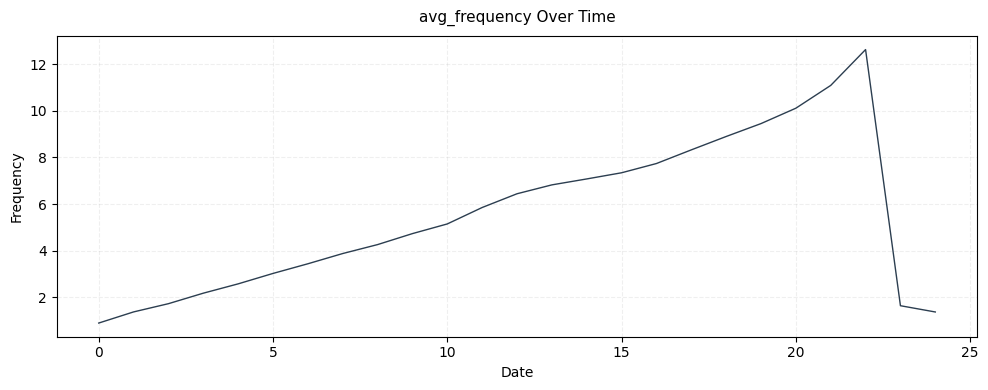

In [9]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(series.index, series.values, linewidth=1, color='#2c3e50')
plt.title('avg_frequency Over Time', fontsize=11, pad=10)
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

lags = [1, 2, 3, 4, 5, 6]

for metric in ['avg_frequency', 'avg_monetary']:
    acf_values = acf(agg[metric], nlags=6, fft=False)
    print(f"\n{metric.upper()}")
    print("-" * 40)
    for lag, val in zip(lags, acf_values[1:7]):
        print(f"Lag {lag}: {val:.3f}")
    
    # Simple interpretation
    if acf_values[1] > 0.7:
        print(f"→ RECOMMENDED α = 0.95 (very persistent)")
    elif acf_values[1] > 0.5:
        print(f"→ RECOMMENDED α = 0.90 (moderately persistent)")
    elif acf_values[1] > 0.3:
        print(f"→ RECOMMENDED α = 0.85 (weakly persistent)")
    else:
        print(f"→ RECOMMENDED α = 0.80 (not persistent)")



AVG_FREQUENCY
----------------------------------------
Lag 1: 0.692
Lag 2: 0.424
Lag 3: 0.353
Lag 4: 0.275
Lag 5: 0.196
Lag 6: 0.122
→ RECOMMENDED α = 0.90 (moderately persistent)

AVG_MONETARY
----------------------------------------
Lag 1: 0.497
Lag 2: 0.284
Lag 3: 0.106
Lag 4: -0.006
Lag 5: -0.093
Lag 6: -0.132
→ RECOMMENDED α = 0.85 (weakly persistent)


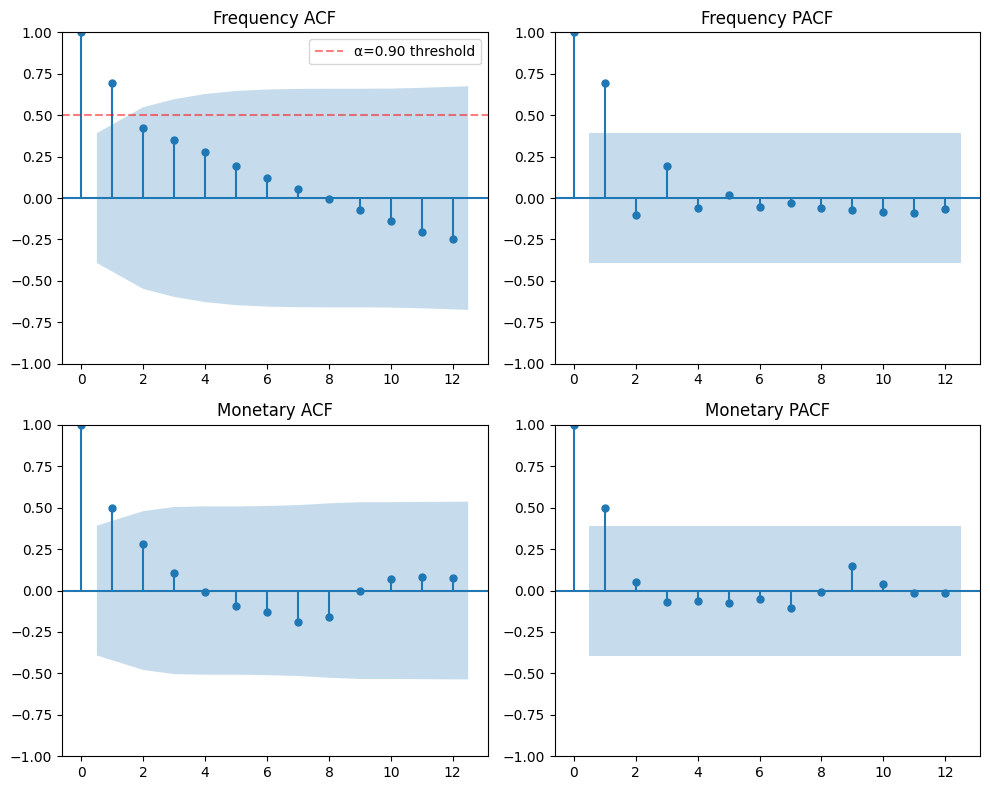

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Frequency ACF
plot_acf(agg['avg_frequency'], lags=12, ax=axes[0,0], title='Frequency ACF')
axes[0,0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='α=0.90 threshold')
axes[0,0].legend()

# Frequency PACF
plot_pacf(agg['avg_frequency'], lags=12, ax=axes[0,1], title='Frequency PACF')

# Monetary ACF
plot_acf(agg['avg_monetary'], lags=12, ax=axes[1,0], title='Monetary ACF')

# Monetary PACF
plot_pacf(agg['avg_monetary'], lags=12, ax=axes[1,1], title='Monetary PACF')

plt.tight_layout()
plt.savefig('fig5.png', dpi=300, bbox_inches='tight')
plt.show()